In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [82]:
df=pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [84]:
df.dropna(subset=['bmi'],inplace=True)

In [85]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [86]:
df.drop(['id'],axis=1,inplace=True)

<Axes: >

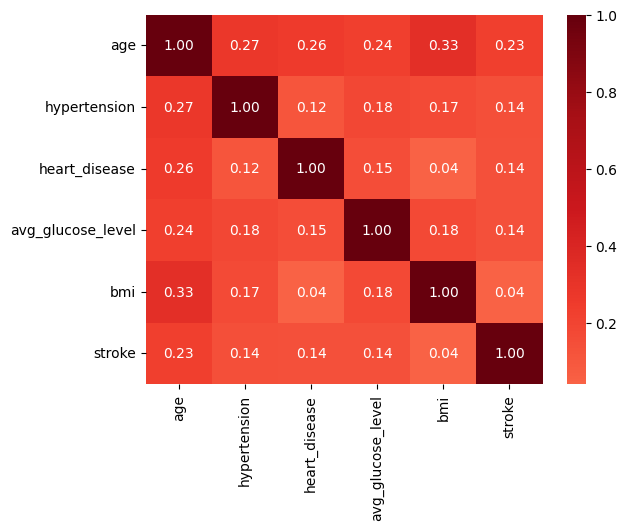

In [87]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='Reds',center=0)

In [88]:
df.corr(numeric_only=True)['stroke']

,stroke
age,0.232331
hypertension,0.142515
heart_disease,0.137938
avg_glucose_level,0.138936
bmi,0.042374
stroke,1.000000


Transform Non Numeric Data

In [89]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [90]:
features=df.select_dtypes(include='object').columns.tolist()
features

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

In [91]:
features_encoded=encoder.fit_transform(df[features].values)
features_encoded.shape

(4909, 16)

In [92]:
data = pd.concat([df,
                  pd.DataFrame(features_encoded,columns=encoder.get_feature_names_out(features))],axis=1).drop(features,axis=1)
data.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0.0,1.0,228.69,36.6,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,80.0,0.0,1.0,105.92,32.5,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,49.0,0.0,0.0,171.23,34.4,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,79.0,1.0,0.0,174.12,24.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5,81.0,0.0,0.0,186.21,29.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [93]:
data.isna().sum()

,0
age,192
hypertension,192
heart_disease,192
avg_glucose_level,192
bmi,192
stroke,192
gender_Female,192
gender_Male,192
gender_Other,192
ever_married_No,192


In [94]:
data.dropna(axis=0, inplace=True)

In [95]:
x= data.drop(['stroke'],axis=1)
y= data.stroke

In [96]:
y.value_counts()

,count
stroke,
0.0,4508
1.0,209


<Axes: ylabel='count'>

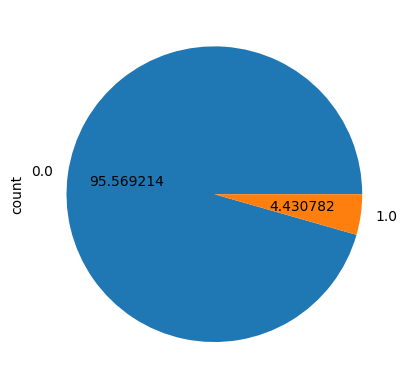

In [97]:
y.value_counts().plot.pie(autopct='%2f')

In [98]:
from  imblearn.under_sampling import RandomUnderSampler

res = RandomUnderSampler()
x_res,y_res = res.fit_resample(x,y)


In [99]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=42)


In [100]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


model = make_pipeline(StandardScaler(),
                     LinearSVC(random_state=0,tol=1e-5,dual='auto'))
model.fit(x_train,y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(random_state=0, tol=1e-05))])

In [101]:
predy = model.predict(x_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report

In [103]:
accuracy_score(y_test,predy)

0.7142857142857143

In [104]:
print(classification_report(y_test,predy))

              precision    recall  f1-score   support

         0.0       0.72      0.69      0.71        42
         1.0       0.70      0.74      0.72        42

    accuracy                           0.71        84
   macro avg       0.71      0.71      0.71        84
weighted avg       0.71      0.71      0.71        84



In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   object 
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   object 
 5   work_type          4909 non-null   object 
 6   Residence_type     4909 non-null   object 
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   object 
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 589.3+ KB


In [106]:
df.work_type.unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [107]:
new_input = pd.DataFrame({
    'gender': ['Male'],
    'age': [56],
    'hypertension': [1],
    'heart_disease': [0],
    'ever_married':['Yes'],
    'work_type':['Private'],
    'Residence_type':['Urban'],
    'avg_glucose_level':[150],
    'bmi':[120],
    'smoking_status':['smokes']
})
new_input


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,56,1,0,Yes,Private,Urban,150,120,smokes


In [108]:

trans_input =encoder.transform(new_input[features].values)

In [109]:
new_input = pd.concat([new_input,
                  pd.DataFrame(trans_input,columns=encoder.get_feature_names_out(features))],axis=1).drop(features,axis=1)

In [111]:
pred = model.predict(new_input)
pred

array([0.])

In [ ]:
import pickle

In [ ]:
data = {'model':model,'encoder':encoder}
with open('pickel_model.pkl','wb') as  file:
  pickle.dump(data, file)